# 🌊 Data Visualization Part 4: Seaborn Masterclass
**From Statistical Abstractions to Beautiful, Publication-Ready Plots**

Welcome to Part 4! Matplotlib gives you total control, but writing 10 lines of code just to make a colored scatter plot is exhausting. Enter **Seaborn**: a library built on top of Matplotlib that integrates seamlessly with Pandas DataFrames and provides stunning statistical visualizations with a single line of code.

Every concept follows our **Mastery Framework**:

`Theory → Mental Model → Diagram → Code → Mistakes → Interview → Practice (Levels 1-5)`

## 🧠 1. Theory: Why Seaborn?
1. **Layer of Abstraction:** Hides complex Matplotlib syntax.
2. **Better Aesthetics:** Beautiful default themes and color palettes.
3. **Pandas Integration:** Natively understands DataFrame columns.
4. **Statistical Power:** Automatically calculates and plots regression lines, confidence intervals, and distributions.

## 💡 2. Mental Model: The Two Types of Functions
Seaborn has two distinct architectures. Understanding this is the key to mastering the library.
- **Axis-Level Functions** (e.g., `scatterplot`, `histplot`): Draw a single plot on the current Matplotlib `Axes`. You can mix and match them.
- **Figure-Level Functions** (e.g., `relplot`, `displot`, `catplot`): Manage the *entire* figure. They create their own Matplotlib figure and are designed for **Faceting** (creating grids of multiple subplots).

## 📊 3. Visual Diagram
```text
AXIS-LEVEL (The Brick)          FIGURE-LEVEL (The Whole Wall)
sns.scatterplot()               sns.relplot()
   ↓                               ↓
[ Single Plot ]                 [ Grid of Plots ]
Returns: Axes object            Returns: FacetGrid object

## 🗺️ Seaborn Roadmap

### Types of Functions
1.  **Axis Level**: Operate on a single `matplotlib.axes.Axes` object. You can combine them using Matplotlib's subplots.
    *   Examples: `sns.scatterplot`, `sns.histplot`, `sns.heatmap`
2.  **Figure Level**: Manage the entire figure, including FacetGrid for subplots. Easier to use for complex multi-plot layouts.
    *   Examples: `sns.relplot`, `sns.displot`, `sns.catplot`

### Main Plot Classifications
1.  **Relational Plot**: Bivariate analysis (scatter, line).
2.  **Distribution Plot**: Univariate analysis (histogram, KDE, rug).
3.  **Categorical Plot**: Categorical comparisons (bar, violin).
4.  **Regression Plot**: Linear relationships.
5.  **Matrix Plot**: Data as color-encoded matrices (heatmap, clustermap).
6.  **Multiplots**: Combining multiple plots (jointplot, pairplot).

## 🎤 4. Interview Question
**Q: What is the fundamental difference between `sns.scatterplot()` and `sns.relplot()`?**
> **A:** `scatterplot()` is an **axis-level** function that plots on a single Matplotlib Axes. `relplot()` is a **figure-level** function that wraps `scatterplot` (or `lineplot`) and allows you to easily create faceted grids (multiple subplots) using the `col` and `row` parameters.


## 💻 Setup & Data Loading
Let's import the necessary libraries and load a sample dataset (`tips` and `flights`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load sample datasets
tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')
iris = sns.load_dataset('iris')

# Set style
sns.set_style("whitegrid")

print("Datasets loaded successfully!")
display(tips.head())

Datasets loaded successfully!


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# 1. 🔗 Relational Plots
### Purpose: Bivariate analysis to see the statistical relationship between 2 or more variables.
### Key Plot Types: `scatterplot`, `lineplot`

### 🔵 Scatter Plot (Axis Level)
Used to visualize the relationship between two numerical variables.

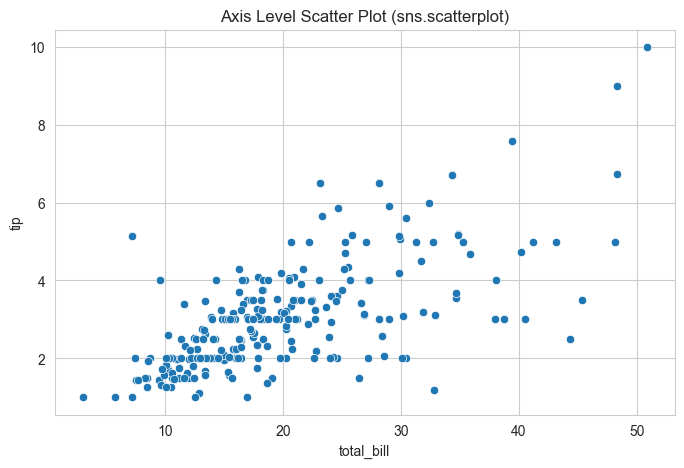

In [2]:
# Axis Level Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip')
plt.title('Axis Level Scatter Plot (sns.scatterplot)')
plt.show()

### 🔴 Scatter Plot using relplot (Figure Level)
Returns a `FacetGrid` object, allowing easy creation of subplots based on categorical variables.

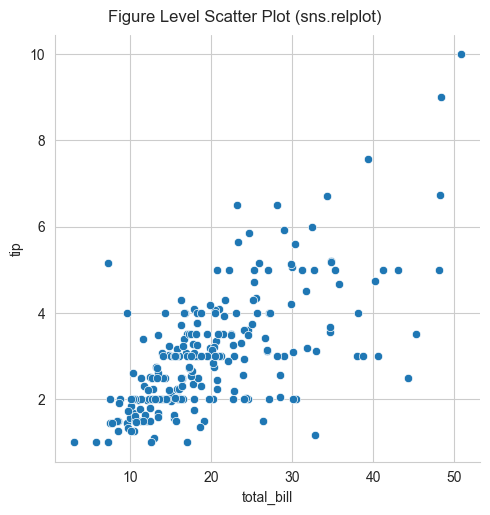

In [3]:
# Figure Level Scatter Plot
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter')
plt.suptitle('Figure Level Scatter Plot (sns.relplot)', y=1.02)
plt.show()

### ❓ Which one to use? `scatterplot` or `relplot`?
*   **`scatterplot` (Axis Level)**: Use when you want a single, customized plot, often combined with Matplotlib subplots (`fig, axes = plt.subplots(1,2)`).
*   **`relplot` (Figure Level)**: Use when you want to easily create faceted subplots using `col` or `row` parameters.

**Analogy**: `scatterplot` is a single actor. `relplot` is a director managing multiple stages.

### ✨ Relational Plots (Scatter & Line: using Parameters: `hue`, `size`, `style`)

Relational plots visualize the statistical relationship between two or more variables. By mapping additional variables to **`hue`** (color), **`size`** (marker area), and **`style`** (marker shape), we can visualize 4+ dimensions in a single 2D plot!

## 💡 2. Mental Model
**The Dashboard of a Car:**
- X-axis = Speed
- Y-axis = RPM
- `hue` = Engine Temperature (Color)
- `size` = Fuel Level (Dot Size)

## 🛠️ 3. Syntax
```python
sns.scatterplot(data=df, x='col1', y='col2', 
                hue='col3', size='col4', style='col5')
```

## ⚠️ 4. Common Mistakes
**Overplotting:** Mapping too many variables to `size` and `style` simultaneously makes the plot look like a chaotic explosion. Stick to 1 or 2 semantic mappings max.

## 🎯 5. Practice Tasks
*   **Level 1 (Easy):** Create a basic scatterplot of `total_bill` vs `tip`.
*   **Level 2 (Medium):** Add `hue='day'` to color the points by the day of the week.
*   **Level 3 (Hard):** Map `size='total_bill'` and `style='smoker'`.
*   **Level 4 (Expert):** Use `sns.relplot()` with `col='time'` and `row='smoker'` to create a 2x2 faceted grid.
*   **Level 5 (Challenge):** Use `col_wrap=2` to wrap a faceted plot of `penguins` by `island` into a neat grid.

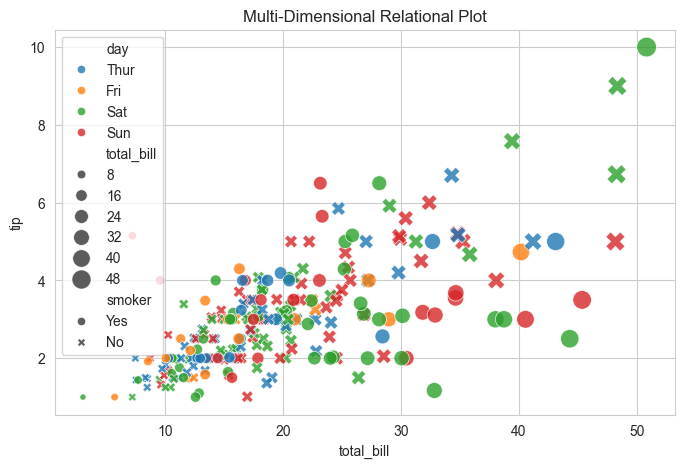

NameError: name 'penguins' is not defined

In [26]:
# ==========================================
# 💻 CODE: RELATIONAL PLOTS
# ==========================================
# 1. Scatterplot with Hue, Size, Style
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip', 
                hue='day', size='total_bill', style='smoker',
                sizes=(20, 200), alpha=0.8)
plt.title("Multi-Dimensional Relational Plot")
plt.show()

# 2. Lineplot (Time Series / Continuous)
# Let's use penguins to see bill length vs depth
sns.relplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', 
            hue='species', kind='line', markers=True, dashes=False)
plt.title("Penguin Bill Dimensions by Species")
plt.show()

# 3. Faceting with col_wrap
sns.relplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', 
            hue='sex', col='island', col_wrap=2, height=4)
plt.show()

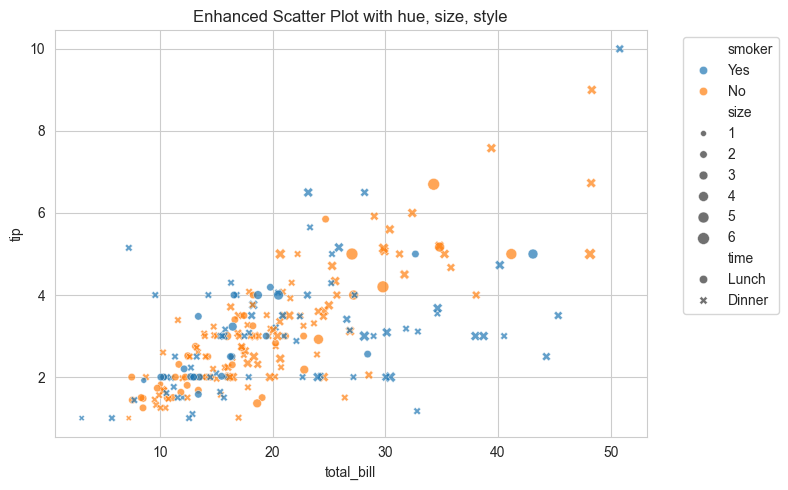

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',      # Color encoding
    size='size',       # Bubble size encoding
    style='time',      # Marker style encoding
    alpha=0.7
)
plt.title('Enhanced Scatter Plot with hue, size, style')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📈 Line Plot
Useful for showing trends, especially over a continuous interval (e.g., time series).

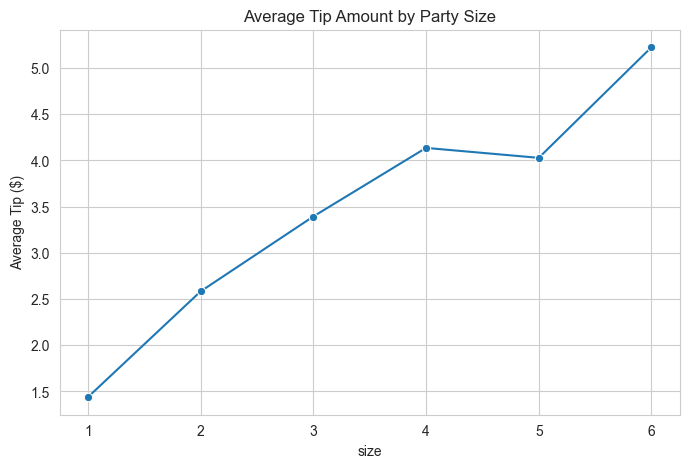

In [6]:
# Aggregate data for line plot
agg_tips = tips.groupby('size')['tip'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=agg_tips, x='size', y='tip', marker='o')
plt.title('Average Tip Amount by Party Size')
plt.ylabel('Average Tip ($)')
plt.show()

### 🗂️ Facet Plot with `relplot`
Create subplots based on categorical columns. This is where figure-level functions shine.

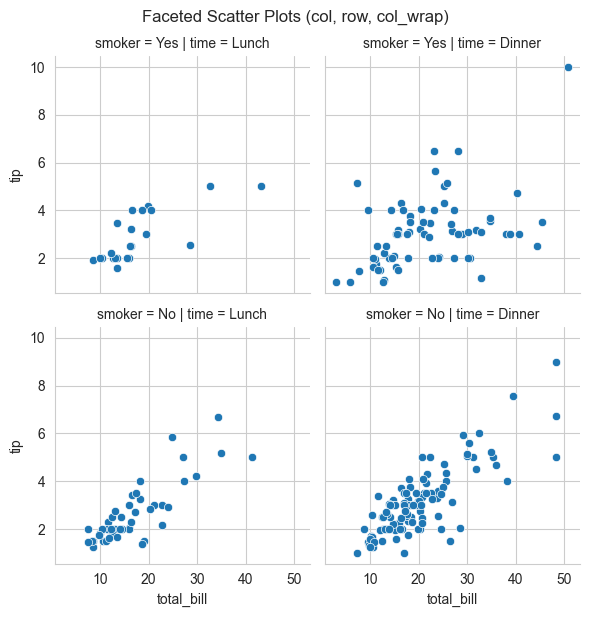

In [7]:
# Facet Grid with relplot
sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    col='time',     # Splits into columns by 'time'
    row='smoker',   # Splits into rows by 'smoker'
    kind='scatter',
    height=3
)
plt.suptitle('Faceted Scatter Plots (col, row, col_wrap)', y=1.02)
plt.show()

### 🎁 `col_wrap` Parameter
Controls how many columns appear in a row before wrapping to the next line. Useful when you have many categories in `col`.

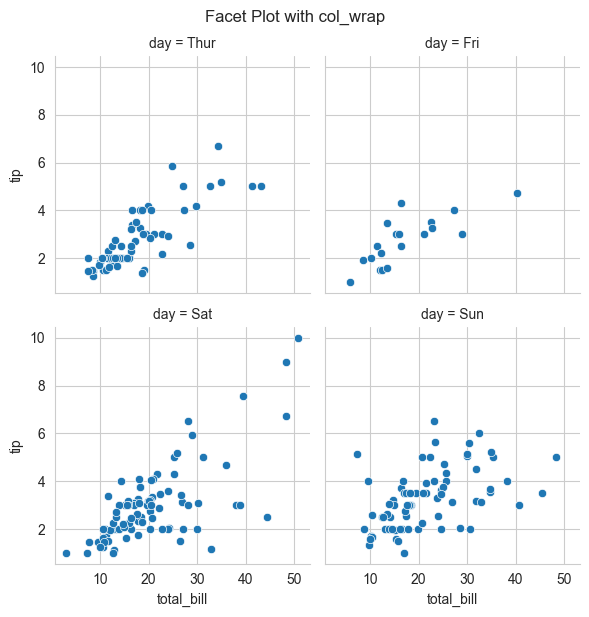

In [8]:
# Using col_wrap with a column having many categories
sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    col='day',
    col_wrap=2,   # 2 columns per row
    kind='scatter',
    height=3
)
plt.suptitle('Facet Plot with col_wrap', y=1.02)
plt.show()

# 2. 📊 Distribution Plots

Distribution plots are used for **Univariate Analysis** (analyzing a single numerical column) to understand the underlying shape of the data.
- **`histplot`**: Bins data into bars (Frequency).
- **`kdeplot`**: Kernel Density Estimate. Draws a smooth, continuous curve over the data.
- **`rugplot`**: Draws a small vertical tick for every single data point along the x-axis.

## 💡 Mental Model
- **Histogram:** Stacking blocks to build a pyramid.
- **KDE:** Draping a smooth silk cloth over those blocks.
- **Rug:** Showing the exact individual threads that make up the cloth.

## 🛠️ Syntax & Parameters
```python
# Histogram
sns.histplot(data=df, x='col', bins=20, kde=True, hue='cat_col', element='step')

# KDE
sns.kdeplot(data=df, x='col', fill=True)

# Rug
sns.rugplot(data=df, x='col')
```

## 🎤 Interview Question
**Q:** What does the `element` parameter do in `sns.histplot()`?
**A:** It changes the visual representation of the histogram. `'bars'` (default) draws standard rectangles. `'step'` draws an outline (like a line chart). `'poly'` draws a polygon connecting the bin midpoints.

## 🎯  Practice Tasks
*   **Level 1:** Plot a basic histogram of `tips['total_bill']`.
*   **Level 2:** Overlay a KDE curve on the histogram using `kde=True`.
*   **Level 3:** Plot the distribution of `total_bill` grouped by `time` using `hue='time'` and `element='step'`.
*   **Level 4 (Bivariate):** Create a 2D histogram using `sns.histplot(x='total_bill', y='tip', bins=20, cmap='Blues')`.
*   **Level 5:** Use `sns.displot()` (figure-level) with `col='day'` and `col_wrap=2` to show distributions for every day.


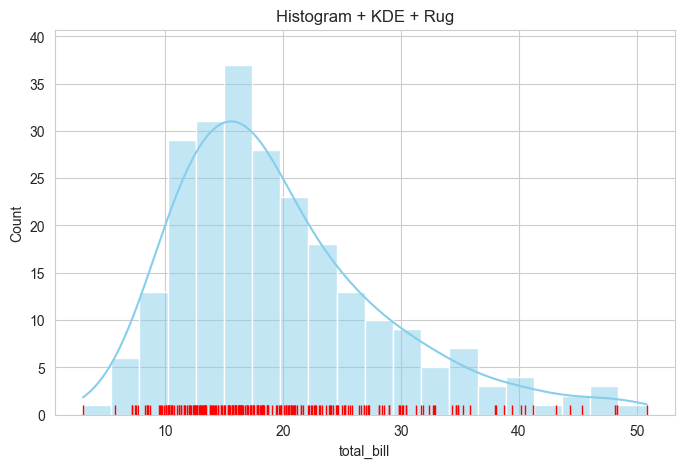

In [28]:
# ==========================================
# 💻 CODE: DISTRIBUTION PLOTS
# ==========================================
# 1. Univariate Histplot + KDE + Rug
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=tips, x='total_bill', bins=20, kde=True, color='skyblue', ax=ax)
sns.rugplot(data=tips, x='total_bill', color='red', ax=ax)
plt.title("Histogram + KDE + Rug")
plt.show()


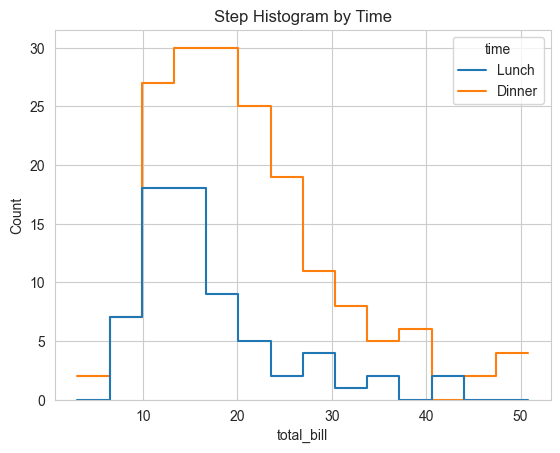

In [29]:
# 2. Categorical Hue & Element='step'
sns.histplot(data=tips, x='total_bill', hue='time', element='step', fill=False)
plt.title("Step Histogram by Time")
plt.show()


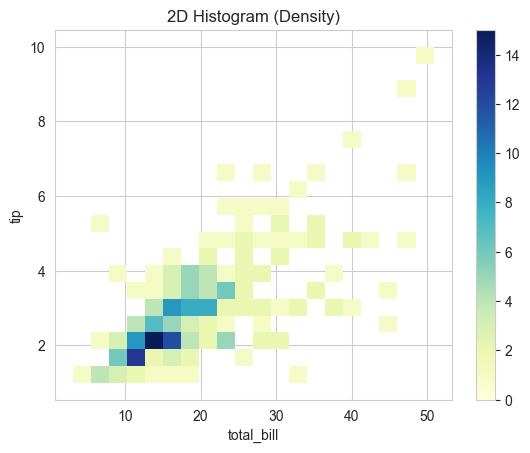

In [30]:
# 3. Bivariate Histogram (2D)
sns.histplot(data=tips, x='total_bill', y='tip', bins=20, cmap='YlGnBu', cbar=True)
plt.title("2D Histogram (Density)")
plt.show()

d:\Projects\personalNotes\.venv\Lib\site-packages\seaborn\distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


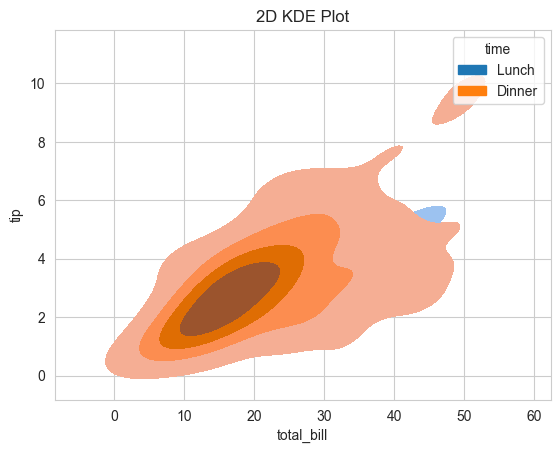

In [31]:
# 4. Bivariate KDE
sns.kdeplot(data=tips, x='total_bill', y='tip', hue='time', fill=True, levels=5, cmap='coolwarm')
plt.title("2D KDE Plot")
plt.show()


### 📊 Histogram (`histplot`)
Bins numeric data into intervals and shows frequency.

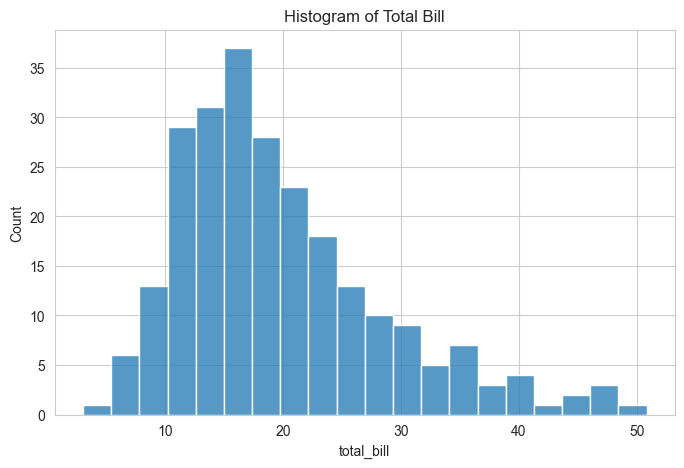

In [9]:
# Basic Histogram (Axis Level)
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x='total_bill', bins=20)
plt.title('Histogram of Total Bill')
plt.show()

### 📊 Histogram using `displot` (Figure Level)
The figure-level equivalent for distribution plots.

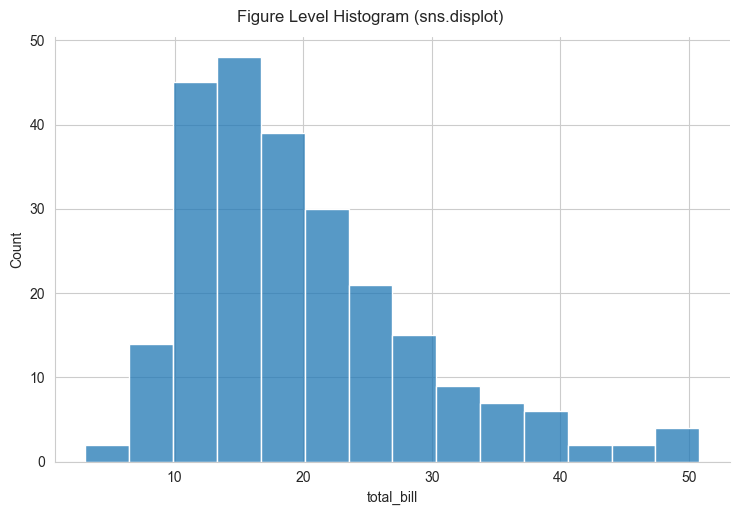

In [10]:
# Figure Level Histogram
sns.displot(data=tips, x='total_bill', kind='hist', height=5, aspect=1.5)
plt.suptitle('Figure Level Histogram (sns.displot)', y=1.02)
plt.show()

### 🔢 `bins` Parameter
Controls the number of bins (intervals) or the bin boundaries.

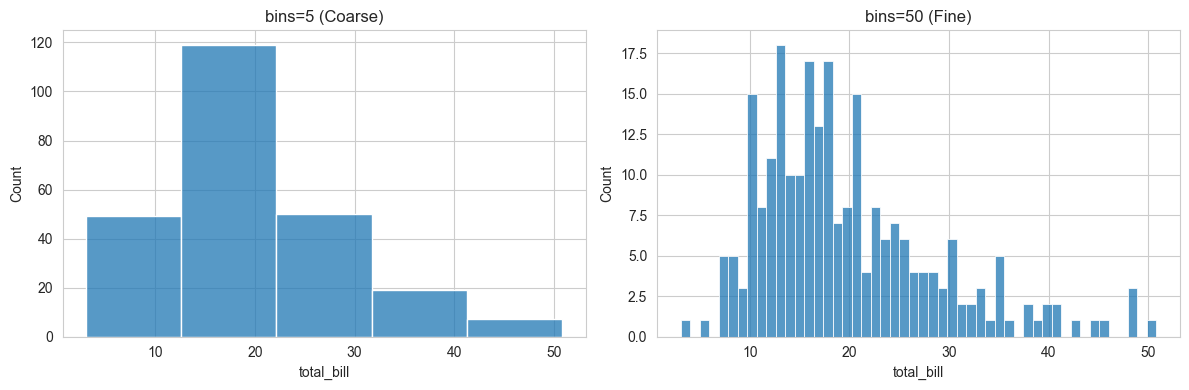

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fewer bins
sns.histplot(data=tips, x='total_bill', bins=5, ax=axes[0])
axes[0].set_title('bins=5 (Coarse)')

# More bins
sns.histplot(data=tips, x='total_bill', bins=50, ax=axes[1])
axes[1].set_title('bins=50 (Fine)')

plt.tight_layout()
plt.show()

### 📊 Histogram on Categorical Column
Plotting counts of categorical data.

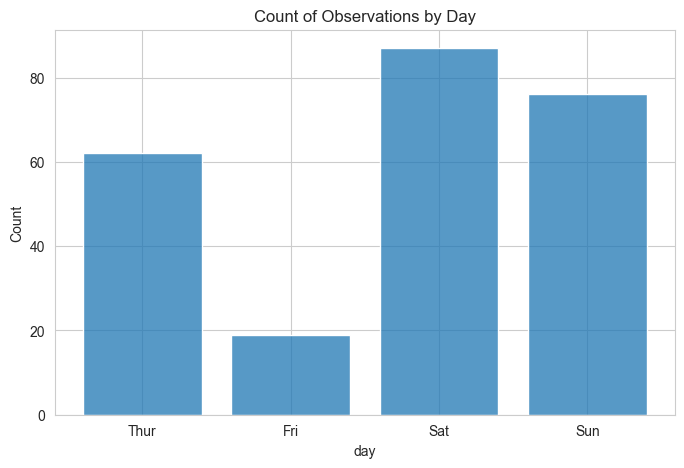

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x='day', shrink=0.8) # shrink adds gaps
plt.title('Count of Observations by Day')
plt.show()

### 🎨 `hue` and `element` Parameters
*   `hue`: Color encode categories.
*   `element`: Visual representation ('bars', 'step', 'poly').

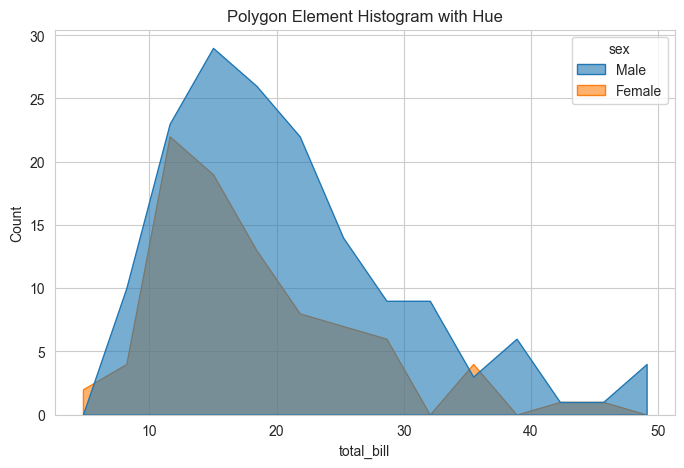

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x='total_bill', hue='sex', element='poly', alpha=0.6)
plt.title('Polygon Element Histogram with Hue')
plt.show()

### 🗂️ Facet Plot with `displot`
Creating faceted histograms.

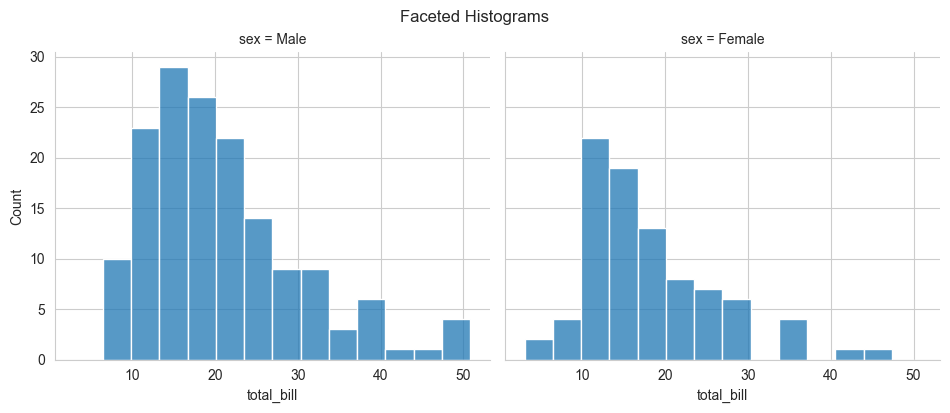

In [14]:
sns.displot(
    data=tips,
    x='total_bill',
    col='sex',
    kind='hist',
    height=4,
    aspect=1.2
)
plt.suptitle('Faceted Histograms', y=1.02)
plt.show()

### 📈 KDE Plot (`kdeplot`)
Kernel Density Estimate — a smooth curve representing the probability density function of the data.

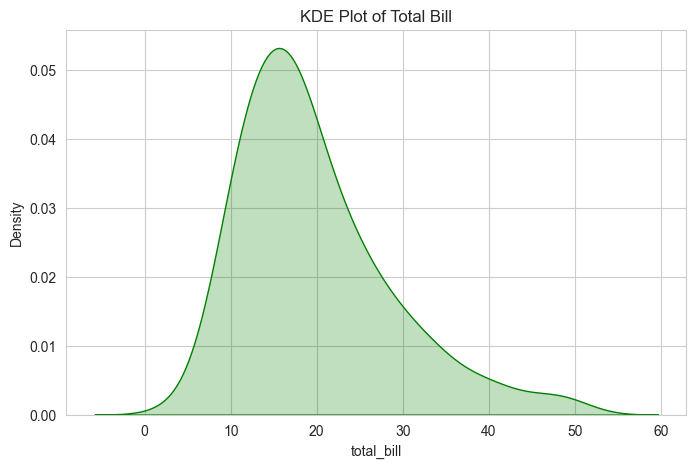

In [15]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=tips, x='total_bill', fill=True, color='green')
plt.title('KDE Plot of Total Bill')
plt.show()

### 🧶 Rug Plot (`rugplot`)
Draws small vertical ticks for every data point, showing density and individual values. Often combined with KDE.

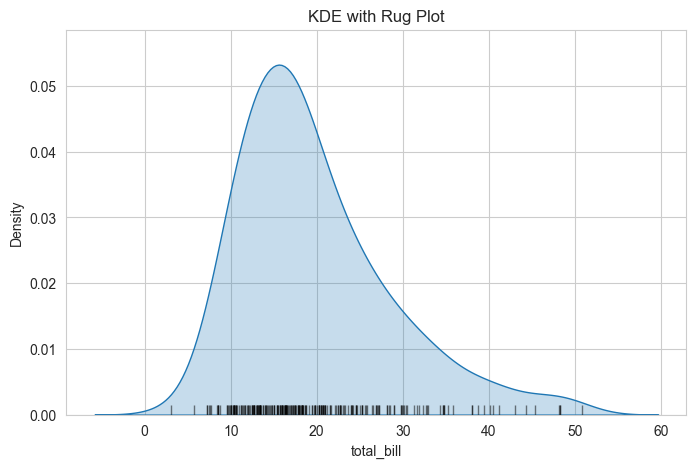

In [16]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=tips, x='total_bill', fill=True)
sns.rugplot(data=tips, x='total_bill', color='black', alpha=0.5)
plt.title('KDE with Rug Plot')
plt.show()

### 📊 Bi-Variate Histogram
Visualizing the joint distribution of two numerical variables.

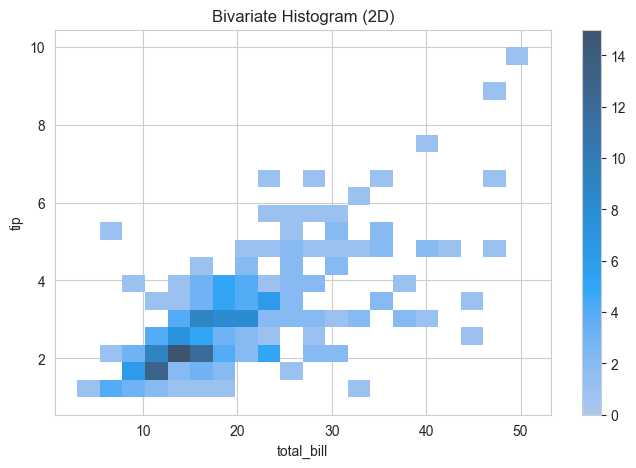

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x='total_bill', y='tip', bins=20, cbar=True)
plt.title('Bivariate Histogram (2D)')
plt.show()

### 📈 Bi-Variate KDE Plot
A smooth 2D density surface.

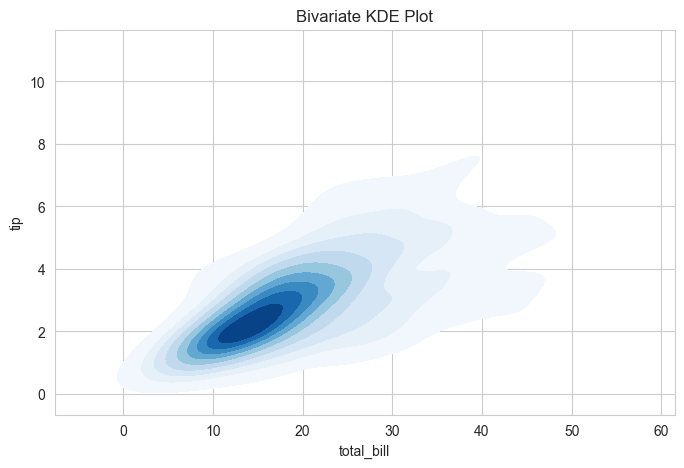

In [18]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=tips, x='total_bill', y='tip', fill=True, cmap='Blues', thresh=0.05)
plt.title('Bivariate KDE Plot')
plt.show()

# 3. 🔥 Matrix Plots
### Purpose: Visualize matrix-like data or correlations as color-encoded grids.

Matrix plots visualize data that is structured in a grid (rows and columns). 
- **`heatmap`**: Colors a 2D matrix based on values. Perfect for **Correlation Matrices** or Pivot Tables.
- **`clustermap`**: A heatmap that uses hierarchical clustering to automatically reorder rows and columns to reveal hidden patterns!

## 💡  Mental Model
A **Thermal Camera** for data. Dark/Hot colors = High numbers. Light/Cold colors = Low numbers.

## 🛠️ Syntax
```python
# Heatmap
sns.heatmap(data_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

# Clustermap
sns.clustermap(data_matrix, cmap='viridis', standard_scale=1)
```

## ⚠️ Common Mistakes
**The "Ugly Diagonal" Trap:** When plotting a correlation matrix, the diagonal is always `1.0` (perfect correlation with itself). This ruins the color scale for the rest of the matrix. 
**Fix:** Mask the upper triangle of the correlation matrix!

## 🎯 Practice Tasks
*   **Level 1:** Plot a heatmap of the `flights_pivot` dataset.
*   **Level 2:** Add annotations (`annot=True`), change the colormap to `'YlOrRd'`, and add `linewidths=0.5`.
*   **Level 3:** Calculate the correlation matrix of the `penguins` numeric columns and plot it as a heatmap.
*   **Level 4:** Create a `clustermap` of the `flights_pivot` data to see which months/years cluster together.
*   **Level 5:** Mask the upper triangle of the penguins correlation matrix so only the lower half is visible.


In [33]:
# ==========================================
# 💻 CODE: MATRIX PLOTS
# ==========================================
# 1. Heatmap (Flights Data)
plt.figure(figsize=(10, 6))
sns.heatmap(flights_pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title("Passenger Flights Heatmap")
plt.show()

# 2. Correlation Heatmap (Penguins)
corr = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

# Masking the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, vmin=-1, vmax=1)
plt.title("Penguins Correlation Matrix (Masked)")
plt.show()

# 3. Clustermap
sns.clustermap(flights_pivot, cmap='magma', standard_scale=1, figsize=(10, 8))
plt.suptitle("Clustermap: Flights Patterns", y=1.02)
plt.show()


NameError: name 'flights_pivot' is not defined

<Figure size 1000x600 with 0 Axes>

### 🔥 Heatmap
Plots rectangular data as a color-encoded matrix. Perfect for correlation matrices.

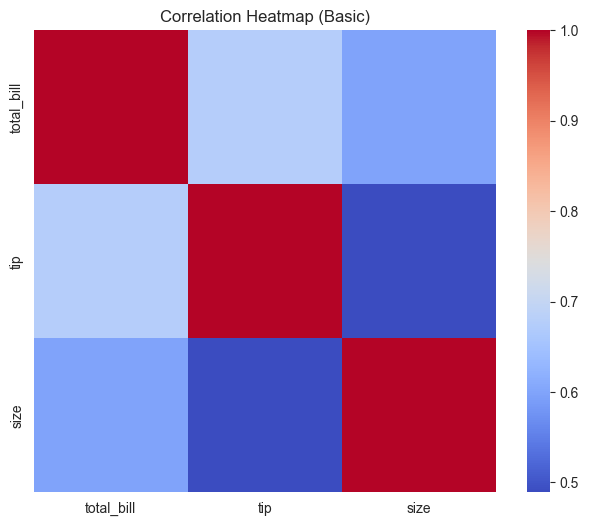

In [19]:
# Compute correlation matrix
corr = tips.select_dtypes(include=np.number).corr()

# Basic Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (Basic)')
plt.show()

### ⚙️ Customizing Heatmap
Adding annotations, controlling line widths, and choosing color maps.

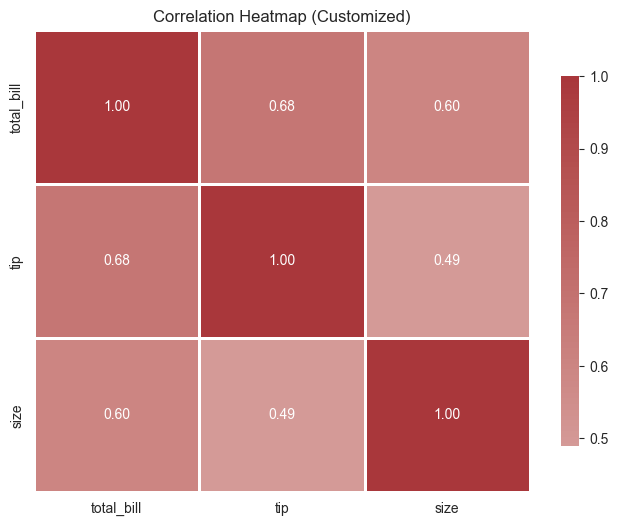

In [20]:
# Advanced Customization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,           # Show values in cells
    fmt=".2f",            # Format to 2 decimal places
    linewidths=0.8,       # Space between cells
    cmap='vlag',          # Diverging colormap
    center=0,             # Center colormap at 0
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap (Customized)')
plt.show()

### 🔬 Clustermap
A heatmap with hierarchical clustering applied to rows and columns, revealing structure in data.

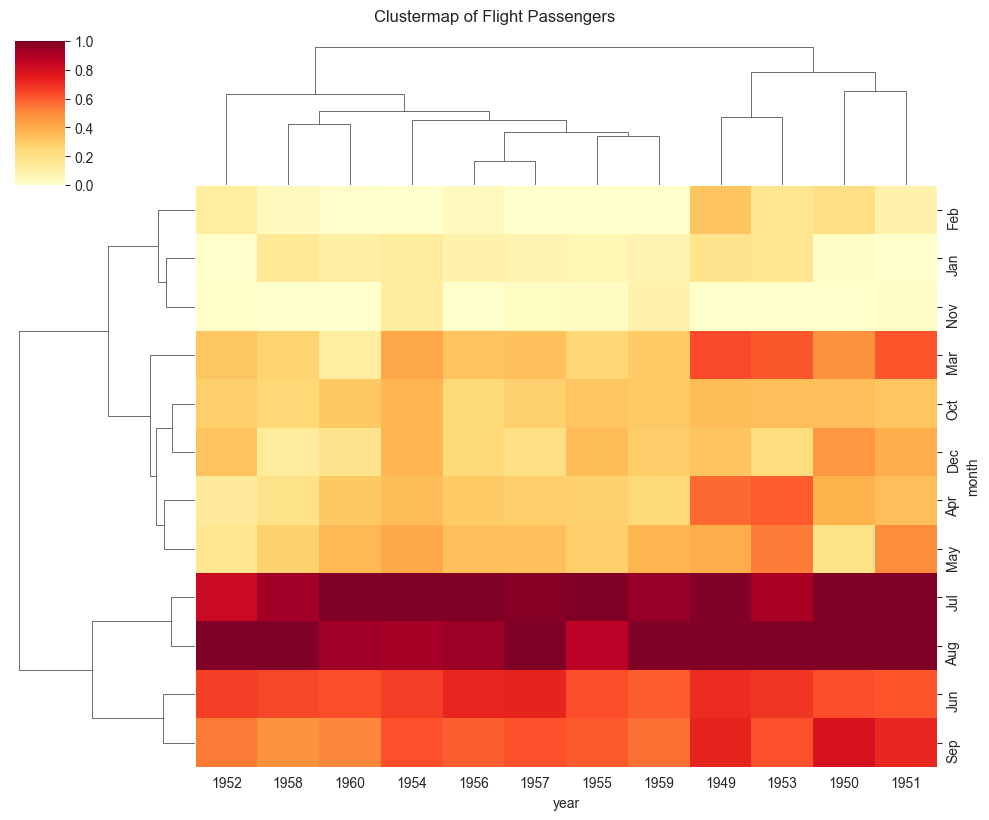

In [21]:
# Prepare pivot table data
pivot_flights = flights.pivot_table(index='month', columns='year', values='passengers')

# Clustermap
cg = sns.clustermap(pivot_flights, cmap='YlOrRd', figsize=(10, 8), standard_scale=1)
cg.fig.suptitle('Clustermap of Flight Passengers', y=1.02)
plt.show()

## 💡 How to Change Size in Figure Level Plots
Figure-level functions (`relplot`, `displot`, `catplot`) use `height` and `aspect` instead of `figsize`.
*   `height`: Height in inches of each facet.
*   `aspect`: Width = height * aspect.
*   `sns.relplot(data=tips, x='total_bill', y='tip', height=6, aspect=1.5)`

## ❓ Doubts & Interview Questions

### Frequently Asked Doubts
1.  **When should I use a KDE plot vs a Histogram?**
    *   Histograms are good for understanding exact counts and bins. KDEs are better for understanding the smooth, underlying shape of the distribution.
    *   **Tip**: Often used together (`sns.histplot(..., kde=True)`).

2.  **What is the difference between a heatmap and a clustermap?**
    *   A heatmap draws the data *as-is* in the given row/column order.
    *   A clustermap performs hierarchical clustering to reorder rows and columns, grouping similar ones together. It's a heatmap + dendrograms.

3.  **How do I save a FacetGrid plot?**
    *   Assign the plot to a variable: `g = sns.relplot(...)`
    *   Save it: `g.savefig('my_plot.png')`

### 🎯 Interview Questions
1.  **What are the main differences between figure-level and axis-level functions in Seaborn? Provide an example of each.**
2.  **Explain how you would visualize the distribution of a single numerical variable and check for outliers. Which Seaborn plots would you use?**
3.  **You have a dataset with columns `Age`, `Income`, `Gender`, and `Region`. How would you visualize the relationship between `Age` and `Income` while also showing the effect of `Gender` using Seaborn?**
4.  **What is a heatmap most commonly used for in Exploratory Data Analysis (EDA)? How do you interpret one?**

<summary>

**Fun Fact:** Did you know Michael Waskom, the creator of Seaborn, worked on it during his PhD in neuroscience at Stanford? He built it to easily visualize neural data, and its name is a playful nod to the *West Wing* character Sam Seaborn, not the ocean creature! 

</summary>

# 📘 Figure-Level Sizing & Customization

## 🧠 1. Theory: How to Change Size in Figure-Level Plots
In Matplotlib, we use `plt.figure(figsize=(10, 6))`. 
But if you try that with a Seaborn **figure-level** function (like `relplot` or `displot`), it gets ignored or causes layout issues because Seaborn manages its own figure creation!

## 💡 2. The Seaborn Way: `height` and `aspect`
Figure-level functions use two parameters to control size:
- **`height`**: The height of *each individual subplot* in inches.
- **`aspect`**: The width-to-height ratio (Width = height × aspect).

## 📊 3. Visual Diagram
```text
Total Width = height * aspect * number_of_columns
Total Height = height * number_of_rows
```

## 💻 4. Code Example


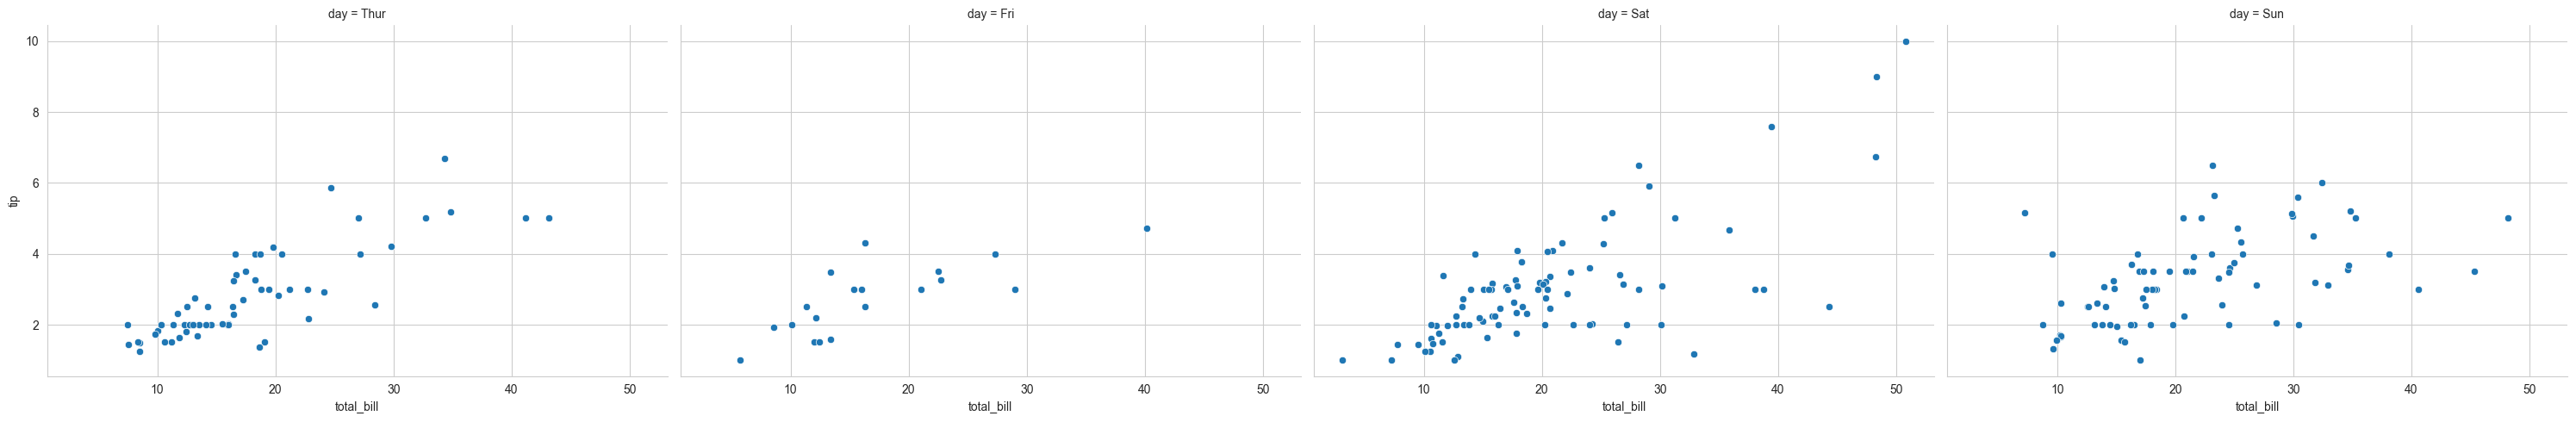

In [34]:
# Make each facet 5 inches tall, and twice as wide as it is tall
sns.relplot(data=tips, x='total_bill', y='tip', col='day', 
            height=5, aspect=1.5)


## 🎤 5. Interview Question
**Q:** Why doesn't `figsize=(12, 6)` work inside `sns.relplot()`?
**A:** Because `relplot` is a figure-level function. It instantiates its own Matplotlib Figure object internally. To change its size, you must use Seaborn's `height` and `aspect` parameters, or use an axis-level function like `scatterplot` inside a manually created `plt.figure(figsize=...)`.

## 🎯 6. Practice Tasks
*   **Level 1:** Create a `relplot` of `tips` faceted by `day` with `height=4` and `aspect=1`.
*   **Level 2:** Create a `displot` of `penguins['bill_length_mm']` faceted by `species` with `height=3, aspect=2`.
*   **Level 3:** Create a `catplot` (box plot) of `tips` with `height=6, aspect=1.5`.
*   **Level 4:** Try to pass `figsize=(10, 5)` into a `relplot` and observe what happens. Then fix it using `height` and `aspect`.
*   **Level 5:** Write a custom function `my_facet_plot(df, x, y, col)` that automatically calculates the optimal `height` and `aspect` based on the number of unique categories in `col`.


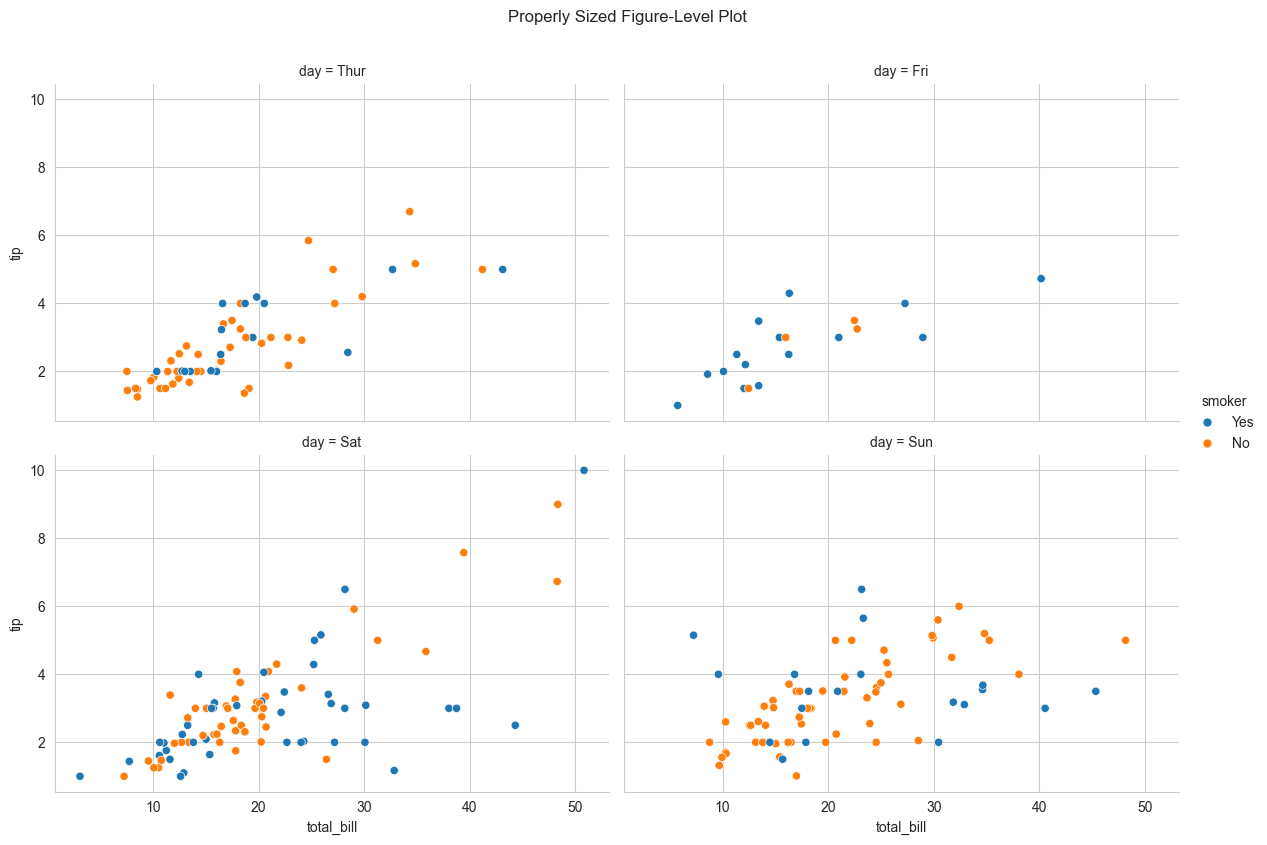

NameError: name 'penguins' is not defined

In [35]:
# ==========================================
# 💻 CODE: FIGURE-LEVEL SIZING
# ==========================================
# Correct way to size figure-level plots
sns.relplot(data=tips, x='total_bill', y='tip', col='day', col_wrap=2,
            height=4, aspect=1.5, hue='smoker')
plt.suptitle("Properly Sized Figure-Level Plot", y=1.05)
plt.show()

# Using displot
sns.displot(data=penguins, x='bill_length_mm', hue='species', 
            kind='kde', fill=True, 
            height=4, aspect=2)
plt.show()


# 🎉 Congratulations!
You have mastered **Data Visualization Part 4: Seaborn**.
You now know how to:

✅ Understand the crucial difference between **Axis-Level** and **Figure-Level** functions.

✅ Build multi-dimensional **Relational Plots** using `hue`, `size`, and `style`.

✅ Analyze data distributions using **Histplots**, **KDEs**, and **Rugplots**.

✅ Visualize matrices and correlations using **Heatmaps** and **Clustermaps**.

✅ Properly size and facet complex dashboards using `height` and `aspect`.

### 🚀 Next Steps
You are now ready for **Data Visualization Part 5: Interactive Dashboards with Plotly & Dash** – taking your static Seaborn plots and making them interactive for the web!
```